In [ ]:
import sys, os
from IPython.display import display, HTML, clear_output
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from cycler import cycler
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter

from pathlib import Path
sys.path.append(str(Path.cwd().parents[1]))
from im_net import datamanager, plotting
import datareader

plot_path = "./figures/Figure1"
plt.rcParams['figure.figsize'] = (2.2, 1.5)
plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({'font.size': 8})

pid_palette = ['#ea535a', '#0066ac', '#9a26c8', '#eebbee', '#cadce0']
paper_palette = ['#1a1a1aff', 'lightgray', '#3ba3ecff', '#f77189ff', '#ff40ffff']
pid_cycler = cycler(color=pid_palette)
sns.set_palette(pid_palette)

alpha_h = 0.14

%load_ext autoreload
%autoreload 2

# Figure 1

## Panel D: PID decomposition of Hebbian networks

PID decomposition of Hebbian-initialised networks without additional training,
showing how information atoms (uniqueness, redundancy, synergy) evolve with
memory load alongside recall accuracy.

**Training command:**
```bash
python src/training.py -m params.pref_gpu=False storage=cluster \
    params.seed='range(20)' params.alpha='range(0.01,2.01,0.05)' \
    params.epochs=0 model=hebbian_start storage.final.pid=True
```

In [ ]:
# TODO: set path to the Hebbian PID experiment folder
pid_path = ''
dm_d = datamanager.DataManager(pid_path, mode='analysis', add_run_properties=True, verbose=0)
datareader.sort_dm(dm_d, 'params.alpha')

n_reps = len(set(dm_d.sel['params.seed']))
n_neurons = dm_d.sel['params.neurons'].iloc[0]
x_alpha = dm_d.sel['params.alpha'][::n_reps]

acc = datareader.group_data_to_numpy(dm_d, 'final', 'acc').reshape(-1, n_reps)
pid_mean = datareader.pid_to_numpy(dm_d, mean=True).reshape(5, -1, n_reps)
print(f"Loaded {dm_d.all.shape[0]} runs ({n_reps} seeds, {len(x_alpha)} alpha values).")

Loaded 800 runs (20 seeds, 40 alpha values).


/tmp/ipykernel_1629875/3597618814.py:19: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim((0, 2))


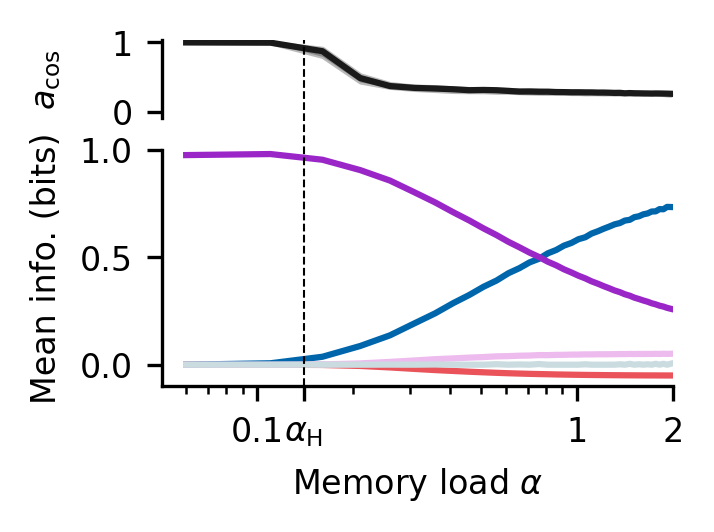

In [3]:
fig, axes = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [1, 3]})
ax = axes[1]

axes[0].set_ylabel(r'$a_{\mathrm{cos}}$')
axes[0].tick_params(axis='x', which='both', labelbottom=False, bottom=False, top=False)
ax.set_xlabel(r'Memory load $\alpha$')
ax.set_ylabel(r'Mean info. (bits)')

for y, tag in zip(pid_mean, datareader.atom_names):
    plotting.plot_mean_and_area(ax, x_alpha[1:], y[1:], mean_ax=1, quantile=0.9, median=True)

plotting.plot_mean_and_area(axes[0], x_alpha[1:], acc[1:],
                            fill_kwargs={'color': paper_palette[0]}, c=paper_palette[0],
                            quantile=0.9, median=True)

plotting.layout_performance(ax, x_lim=(0, 2), y_lim=(0, 1), x_log=True,
                            show_legend=False, border_x=(0, 0), border_y=(0.1, 0))
ax.xaxis.set_major_formatter(FormatStrFormatter('%g'))
ax.set_xlim((0, 2))
ax.set_xticks([0.1, 1, 2])
ax.set_xticklabels(['0.1', '1', '2'])
axes[0].set_ylim((-0.1, 1.04))

for loc, spine in ax.spines.items():
    if loc in ['right', 'top']:
        spine.set_color('none')
for loc, spine in axes[0].spines.items():
    if loc in ['right', 'top', 'bottom']:
        spine.set_color('none')

fig.align_ylabels([axes[0], ax])

# Draw vertical line for alpha_H spanning both subplots via figure coordinates
ax_coord = ((np.log(alpha_h) - np.log(ax.get_xlim()[0]))
            / (np.log(ax.get_xlim()[1]) - np.log(ax.get_xlim()[0])))
trafo = ax.transAxes.transform((ax_coord, 0))[0]
xf = fig.transFigure.inverted().transform((trafo, 0))[0]
fig.lines.append(plt.Line2D([xf, xf], [0.11, 0.88], transform=fig.transFigure,
                             c='k', linestyle='--', linewidth=0.5))
ax.set_xticks(list(ax.get_xticks()) + [alpha_h],
              ax.get_xticklabels() + [r'$\alpha_\mathrm{H}$'])
# fig.savefig(f"{plot_path}/pid_profile_logscale.svg", bbox_inches='tight')